# Cluster Analysis

Cluster analysis, or clustering, is an unsupervised machine learning task. It involves automatically discovering natural grouping in data. Unlike supervised learning (like regression or classification), clustering algorithms do not have labeled outputs to learn from.

## Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering, KMeans, DBSCAN
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch

## Data Generation

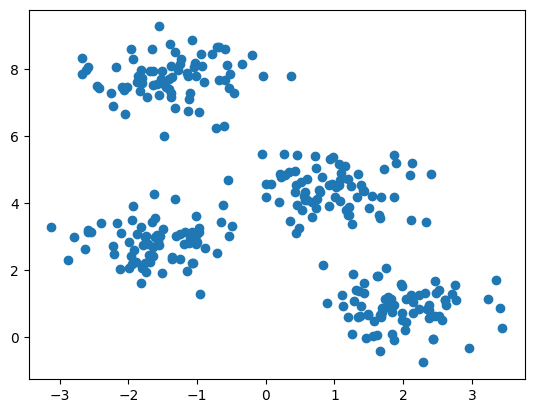

In [2]:
X, y = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)
plt.scatter(X[:,0], X[:,1])

## Hierarchical Clustering

Hierarchical clustering is a method of cluster analysis which seeks to build a hierarchy of clusters. There are two main strategies: 

* Agglomerative: This is a "bottom-up" approach: each observation starts in its own cluster, and pairs of clusters are merged as one moves up the hierarchy.
* Divisive: This is a "top-down" approach: all observations start in one cluster, and splits are performed recursively as one moves down the hierarchy.

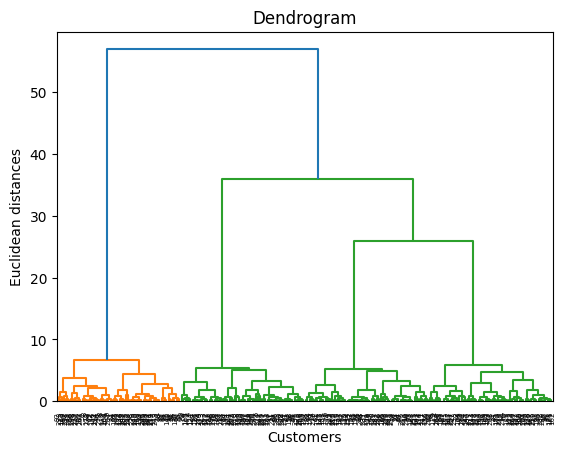

In [3]:
dendrogram = sch.dendrogram(sch.linkage(X, method='ward'))
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.show()

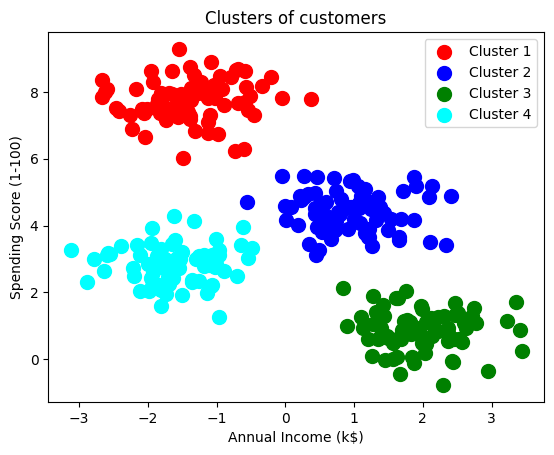

In [4]:
hc = AgglomerativeClustering(n_clusters=4, linkage='ward')
y_hc = hc.fit_predict(X)
plt.scatter(X[y_hc ==0,0], X[y_hc == 0,1], s=100, c='red', label ='Cluster 1')
plt.scatter(X[y_hc==1,0], X[y_hc == 1,1], s=100, c='blue', label ='Cluster 2')
plt.scatter(X[y_hc ==2,0], X[y_hc == 2,1], s=100, c='green', label ='Cluster 3')
plt.scatter(X[y_hc == 3,0], X[y_hc == 3,1], s=100, c='cyan', label ='Cluster 4')
plt.title('Clusters of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

## K-Means Clustering

K-Means clustering is a popular unsupervised machine learning algorithm used for partitioning a dataset into a set of k groups (clusters), where k represents the number of groups pre-specified by the analyst. It groups the data points into clusters based on their similarity. The algorithm works as follows:

1. Choose the number of clusters, k.
2. Initialize k centroids randomly.
3. Assign each data point to the nearest centroid.
4. Re-calculate the centroids of the new clusters.
5. Repeat steps 3 and 4 until the centroids no longer change.

### Selecting the best value of K

#### Elbow Method

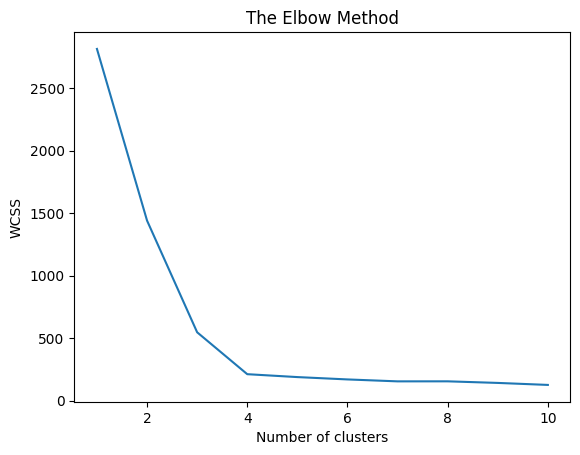

In [5]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

#### Silhouette Score

In [6]:
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    score = silhouette_score(X, kmeans.labels_)
    print(f'For n_clusters={i}, the silhouette score is {score}')

For n_clusters=2, the silhouette score is 0.4546802473065816
For n_clusters=3, the silhouette score is 0.5890390393551768
For n_clusters=4, the silhouette score is 0.6819938690643478
For n_clusters=5, the silhouette score is 0.5923027677672242
For n_clusters=6, the silhouette score is 0.4942157438930076
For n_clusters=7, the silhouette score is 0.42209738926832063
For n_clusters=8, the silhouette score is 0.4907684716680701
For n_clusters=9, the silhouette score is 0.477096640146303
For n_clusters=10, the silhouette score is 0.39434059958404155


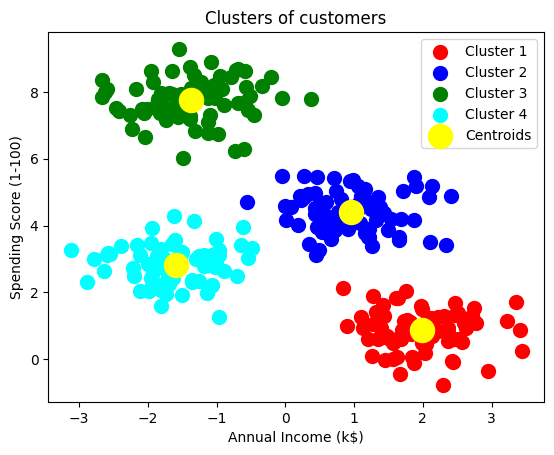

In [7]:
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X)
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s = 100, c = 'red', label = 'Cluster 1')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s = 100, c = 'blue', label = 'Cluster 2')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s = 100, c = 'green', label = 'Cluster 3')
plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], s = 100, c = 'cyan', label = 'Cluster 4')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s = 300, c = 'yellow', label = 'Centroids')
plt.title('Clusters of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

## DBSCAN

Density-Based Spatial Clustering of Applications with Noise (DBSCAN) is a popular unsupervised machine learning algorithm used for clustering. It is particularly effective at finding clusters of arbitrary shapes and identifying noise points. The algorithm works as follows:

1.  **Core Points:** A point is a core point if it has at least a specified number of points (MinPts) within a given distance (epsilon).
2.  **Border Points:** A point is a border point if it is within epsilon of a core point but has fewer than MinPts points within epsilon.
3.  **Noise Points:** A point that is not a core point or a border point is a noise point.


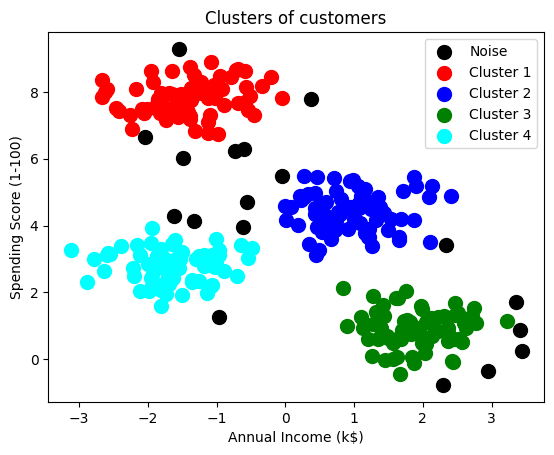

In [8]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
y_dbscan = dbscan.fit_predict(X)
plt.scatter(X[y_dbscan == -1, 0], X[y_dbscan == -1, 1], s = 100, c = 'black', label = 'Noise')
plt.scatter(X[y_dbscan == 0, 0], X[y_dbscan == 0, 1], s = 100, c = 'red', label = 'Cluster 1')
plt.scatter(X[y_dbscan == 1, 0], X[y_dbscan == 1, 1], s = 100, c = 'blue', label = 'Cluster 2')
plt.scatter(X[y_dbscan == 2, 0], X[y_dbscan == 2, 1], s = 100, c = 'green', label = 'Cluster 3')
plt.scatter(X[y_dbscan == 3, 0], X[y_dbscan == 3, 1], s = 100, c = 'cyan', label = 'Cluster 4')
plt.title('Clusters of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()